<a href="https://colab.research.google.com/github/KaabiHiba/FER-CE-Project/blob/main/Hiba_version_pr%C3%A9finale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ====================== TROUVER LE NOM EXACT DE TON NOTEBOOK ======================

import os
import glob

print("📂 Fichiers dans /content :")
!ls -la /content

print("\n🔍 Recherche de tous les fichiers .ipynb dans Colab :")
notebooks = glob.glob("**/*.ipynb", recursive=True)

if notebooks:
    print(f"✅ {len(notebooks)} notebook(s) trouvé(s) :")
    for nb in notebooks:
        print("   →", nb)
else:
    print("❌ Aucun fichier .ipynb trouvé avec glob.")

print("\n📍 Chemin actuel :", os.getcwd())

📂 Fichiers dans /content :
total 16
drwxr-xr-x 1 root root 4096 Mar 30 13:34 .
drwxr-xr-x 1 root root 4096 Apr 15 12:31 ..
drwxr-xr-x 4 root root 4096 Mar 30 13:34 .config
drwxr-xr-x 1 root root 4096 Mar 30 13:34 sample_data

🔍 Recherche de tous les fichiers .ipynb dans Colab :
❌ Aucun fichier .ipynb trouvé avec glob.

📍 Chemin actuel : /content


In [2]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_PATH = "/content/drive/MyDrive/compound"
IMAGE_PATH = os.path.join(BASE_PATH, "Image/aligned")
LABEL_PATH = os.path.join(BASE_PATH, "EmoLabel/list_patition_label.txt")

labels_dict = {}

with open(LABEL_PATH, "r") as f:
    for line in f:
        name, label = line.strip().split()
        labels_dict[name] = int(label) - 1  # 🔥 start from 0

In [5]:
train_images = []
test_images = []

for name in labels_dict.keys():
    if "train" in name:
        train_images.append(name)
    else:
        test_images.append(name)

print(len(train_images), len(test_images))

3162 792


In [6]:
class EmotionDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        real_name = img_name.replace(".jpg", "_aligned.jpg")
        img_path = os.path.join(IMAGE_PATH, real_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            # Return black image + correct label to avoid crashing
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        label = labels_dict[img_name]
        return image, label

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [8]:

train_data, val_data = train_test_split(train_images, test_size=0.2, random_state=42)

train_dataset = EmotionDataset(train_data, transform=train_transform)
val_dataset = EmotionDataset(val_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, drop_last=True, num_workers=2)

In [9]:
labels_array = [labels_dict[x] for x in train_data]

num_classes = 14
class_weights = np.ones(num_classes)

unique_classes = np.unique(labels_array)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=labels_array
)

for i, c in enumerate(unique_classes):
    class_weights[c] = computed_weights[i]

weights = torch.tensor(class_weights, dtype=torch.float)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


In [11]:
model = models.resnet18(weights="DEFAULT")

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(512, 14)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


In [12]:

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [13]:
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [14]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=2,
    factor=0.3
)

In [15]:
num_epochs = 25
best_acc = 0

for epoch in range(num_epochs):
    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")

    model.train()
    running_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")

    # VALIDATION
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    print(f"✅ Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}%")

    scheduler.step(acc)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        print("🔥 Best model saved!")



🚀 Epoch 1/25
Batch 0/79 - Loss: 2.7352
Batch 20/79 - Loss: 2.8539
Batch 40/79 - Loss: 2.4246
Batch 60/79 - Loss: 2.6821
✅ Epoch 1 | Loss: 2.5168 | Acc: 17.11%
🔥 Best model saved!

🚀 Epoch 2/25
Batch 0/79 - Loss: 2.0299
Batch 20/79 - Loss: 2.1020
Batch 40/79 - Loss: 2.0424
Batch 60/79 - Loss: 2.1455
✅ Epoch 2 | Loss: 2.1756 | Acc: 27.63%
🔥 Best model saved!

🚀 Epoch 3/25
Batch 0/79 - Loss: 2.0751
Batch 20/79 - Loss: 1.9153
Batch 40/79 - Loss: 1.9545
Batch 60/79 - Loss: 1.6255
✅ Epoch 3 | Loss: 1.9561 | Acc: 30.26%
🔥 Best model saved!

🚀 Epoch 4/25
Batch 0/79 - Loss: 1.8439
Batch 20/79 - Loss: 1.6513
Batch 40/79 - Loss: 1.8067
Batch 60/79 - Loss: 1.4921
✅ Epoch 4 | Loss: 1.8327 | Acc: 29.11%

🚀 Epoch 5/25
Batch 0/79 - Loss: 1.9918
Batch 20/79 - Loss: 1.8459
Batch 40/79 - Loss: 1.7080
Batch 60/79 - Loss: 1.7963
✅ Epoch 5 | Loss: 1.6446 | Acc: 30.92%
🔥 Best model saved!

🚀 Epoch 6/25
Batch 0/79 - Loss: 1.3612
Batch 20/79 - Loss: 1.6613
Batch 40/79 - Loss: 1.4674
Batch 60/79 - Loss: 1.5540

In [16]:
class_names = [
    "Neutral", "Happy", "Sad", "Surprise",
    "Fear", "Disgust", "Angry", "Contempt",
    "Happily Surprised", "Sadly Angry",
    "Sadly Surprised", "Fearfully Surprised",
    "Angrily Surprised", "Disgustedly Surprised"
]

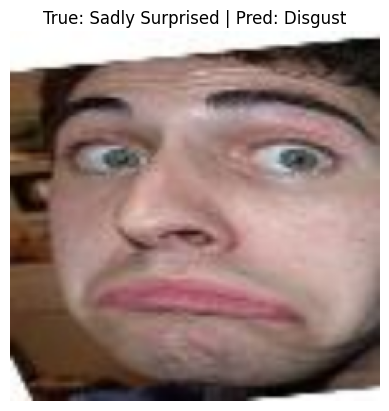

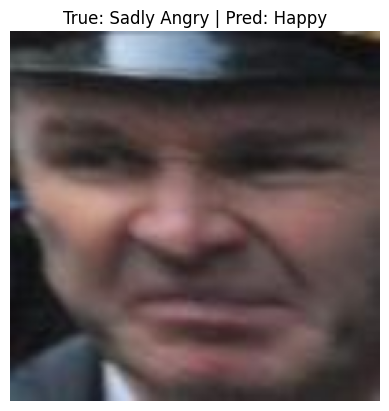

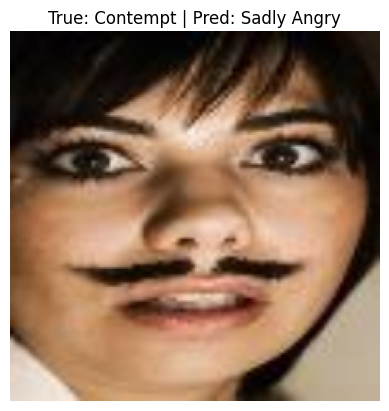

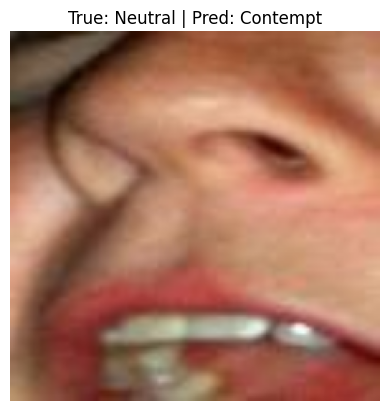

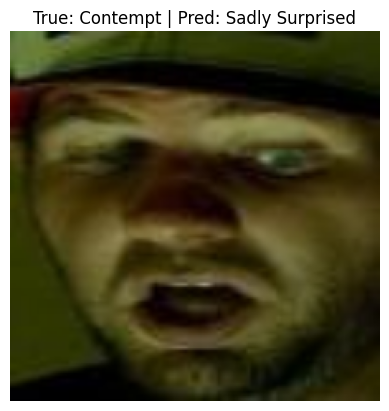

In [17]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

import matplotlib.pyplot as plt
import random

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    img_show = img.permute(1,2,0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5

    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()

              precision    recall  f1-score   support

           0       0.55      0.63      0.59       100
           1       0.37      0.41      0.39        49
           2       0.11      0.09      0.10        23
           3       0.31      0.38      0.34        21
           4       0.12      0.12      0.12        17
           5       0.52      0.50      0.51       118
           6       0.46      0.58      0.51        19
           7       0.55      0.51      0.53        76
           8       0.23      0.24      0.23        29
           9       0.58      0.52      0.55       127
          10       0.22      0.21      0.21        29

    accuracy                           0.47       608
   macro avg       0.37      0.38      0.37       608
weighted avg       0.47      0.47      0.46       608



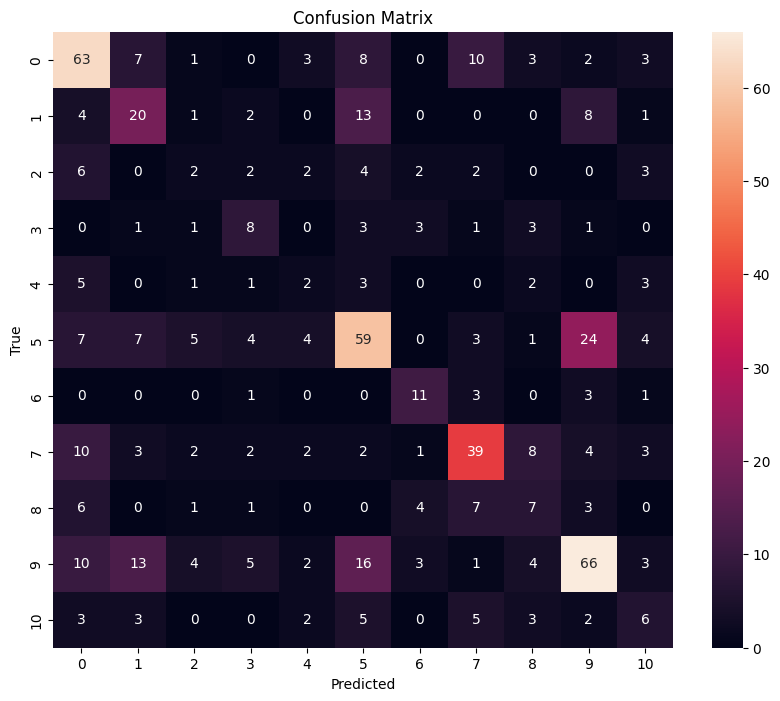

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Report
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [22]:
!pip install open_clip_torch streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print("✅ Imports supplémentaires ajoutés pour CLIP + Grad-CAM + Streamlit")

✅ Imports supplémentaires ajoutés pour CLIP + Grad-CAM + Streamlit


In [24]:
import torch
import open_clip
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_clip, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model_clip = model_clip.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [26]:
text_prompts = [
    "a person smiling with raised eyebrows",
    "a person with angry eyebrows and sad mouth",
    "a person with wide eyes and disgusted face",
    "a smiling person with slight disgust",
    "a sad person with fearful eyes",
    "an angry person with surprised expression",
    "a sad person with raised eyebrows",
    "a disgusted person with surprised face",
    "a person with wide eyes and open mouth",
    "an angry person with disgust expression",
    "a sad person with disgust expression",
    "a smiling person with anger",
    "a fearful person with anger",
    "a neutral face"
]

In [27]:
text_tokens = open_clip.tokenize(text_prompts).to(device)

def predict_clip(image):
    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model_clip.encode_image(image_input)
        text_features = model_clip.encode_text(text_tokens)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T
        probs = logits.softmax(dim=-1)

    pred = probs.argmax().item()
    return pred, probs[0][pred].item()

In [28]:
optimizer_clip = torch.optim.Adam(model_clip.parameters(), lr=1e-5)

def train_clip_one_epoch(loader):
    model_clip.train()

    for images, labels in loader:
        images = images.to(device)

        texts = [text_prompts[l.item()] for l in labels]
        text = open_clip.tokenize(texts).to(device)

        image_features = model_clip.encode_image(images)
        text_features = model_clip.encode_text(text)

        # Fix: Changed inplace division to out-of-place assignment
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T

        loss = torch.nn.CrossEntropyLoss()(logits, torch.arange(len(images)).to(device))

        optimizer_clip.zero_grad()
        loss.backward()
        optimizer_clip.step()

🚀 Évaluation complète CLIP sur le validation set (RAF-CE)...
✅ CLIP Evaluation terminée !
                       precision    recall  f1-score   support

              Neutral       0.44      0.14      0.21       100
                Happy       0.04      0.02      0.03        49
                  Sad       0.00      0.00      0.00        23
             Surprise       0.17      0.05      0.07        21
                 Fear       0.00      0.00      0.00        17
              Disgust       0.06      0.03      0.04       118
                Angry       0.00      0.00      0.00        19
             Contempt       0.33      0.24      0.28        76
    Happily Surprised       0.04      0.24      0.07        29
          Sadly Angry       0.43      0.40      0.42       127
      Sadly Surprised       0.03      0.07      0.05        29
  Fearfully Surprised       0.00      0.00      0.00         0
    Angrily Surprised       0.00      0.00      0.00         0
Disgustedly Surprised      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


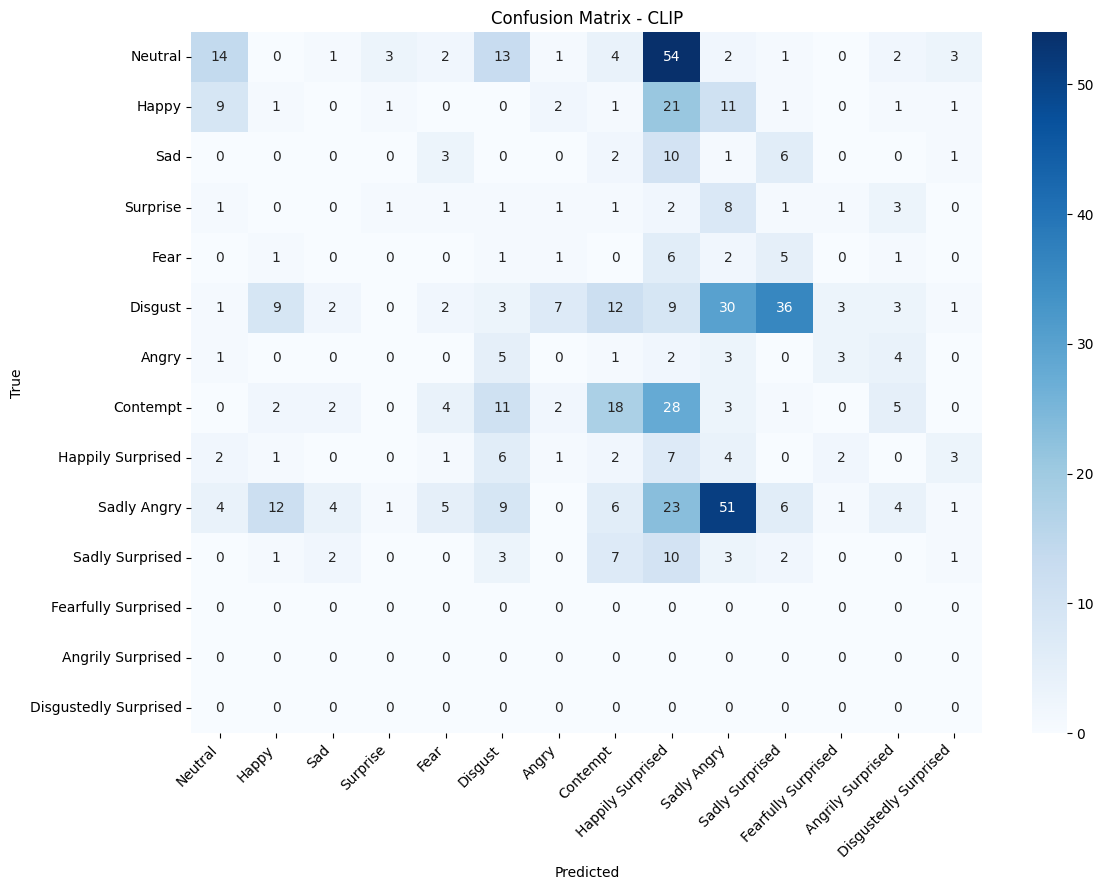

Average CLIP confidence: 0.0726


In [30]:
# ====================== ÉVALUATION CLIP SUR VAL DATASET ======================
print("🚀 Évaluation complète CLIP sur le validation set (RAF-CE)...")

y_true_clip = []
y_pred_clip = []
clip_confidences = []

model_clip.eval()

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):
        for j in range(images.size(0)):  # une image à la fois car predict_clip prend PIL
            img_tensor = images[j]
            # reconvertir en PIL pour predict_clip
            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = (img_np * 0.5) + 0.5
            img_pil = Image.fromarray((img_np * 255).astype(np.uint8))

            pred, conf = predict_clip(img_pil)
            y_pred_clip.append(pred)
            y_true_clip.append(labels[j].item())
            clip_confidences.append(conf)

print("✅ CLIP Evaluation terminée !")

# Rapport
print(classification_report(y_true_clip, y_pred_clip, target_names=class_names))

# Confusion matrix CLIP
cm_clip = confusion_matrix(y_true_clip, y_pred_clip)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_clip, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - CLIP")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Average CLIP confidence: {np.mean(clip_confidences):.4f}")

In [29]:
def predict_all_advanced(image):
    # CNN
    img = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    # GradCAM
    cam = gradcam.generate(img, pred_cnn)

    img_np = np.array(image.resize((224,224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap)/255
    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    # CLIP
    pred_clip, conf_clip = predict_clip(image)

    # Explanation
    explanation = generate_explanation(pred_cnn, cam)

    return (
        f"{class_names[pred_cnn]} ({probs[0][pred_cnn]*100:.2f}%)",
        f"{class_names[pred_clip]} ({conf_clip*100:.2f}%)",
        superimposed,
        explanation
    )

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [32]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        self.model.zero_grad()

        output = self.model(input_image)
        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

In [64]:
target_layer = model.layer4
gradcam = GradCAM(model, target_layer)

In [66]:
def analyze_attention(cam):
    h = cam.shape[0]
    top = cam[:h//3]
    bottom = cam[2*h//3:]

    if np.mean(top) > np.mean(bottom):
        return "eyes"
    else:
        return "mouth"

def generate_explanation(pred, cam):
    focus = analyze_attention(cam)
    return f"Emotion '{class_names[pred]}' detected based on {focus} region."

In [67]:
# ====================== FINE-TUNING CLIP AMÉLIORÉ (sans toucher ton code original) ======================
print("🔄 Fine-tuning CLIP amélioré (5 epochs au lieu de 2)...")

for epoch_ft in range(5):
    train_clip_one_epoch(train_loader)
    print(f"✅ Epoch fine-tuning CLIP {epoch_ft+1}/5 terminé")

# Sauvegarde (comme tu fais pour ResNet)
torch.save(model_clip.state_dict(), "/content/drive/MyDrive/best_clip_model.pth")
print("🔥 Meilleur modèle CLIP sauvegardé dans Drive !")

🔄 Fine-tuning CLIP amélioré (5 epochs au lieu de 2)...
✅ Epoch fine-tuning CLIP 1/5 terminé
✅ Epoch fine-tuning CLIP 2/5 terminé
✅ Epoch fine-tuning CLIP 3/5 terminé
✅ Epoch fine-tuning CLIP 4/5 terminé
✅ Epoch fine-tuning CLIP 5/5 terminé
🔥 Meilleur modèle CLIP sauvegardé dans Drive !


In [68]:
def compare_predictions(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

    print("Prediction ResNet:", pred.item())

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred.item())

    plt.imshow(cam, cmap='jet')
    plt.title("Zones importantes (Grad-CAM)")
    plt.axis('off')
    plt.show()

In [69]:
def generate_explanation(pred_class, cam):
    """Version corrigée : prend le cam (array) et analyse la zone"""
    emotion = class_names[pred_class]

    # Analyse de la zone (ta fonction existante)
    focus_area = analyze_attention(cam)

    if focus_area == "eyes":
        focus_text = "the eyes and eyebrows region"
    elif focus_area == "mouth":
        focus_text = "the mouth and lower face"
    else:
        focus_text = "the central facial region"

    explanation = f"The model predicts '{emotion}' because it focuses mainly on {focus_text}."

    return explanation

In [70]:
def predict_all_advanced_fixed(image):
    """Version corrigée et sécurisée de predict_all_advanced (utilise tes fonctions existantes)"""
    # CNN
    img_tensor = val_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    # Grad-CAM
    cam = gradcam.generate(img_tensor, pred_cnn)

    img_np = np.array(image.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed = heatmap + np.float32(img_np) / 255.0
    superimposed = superimposed / np.max(superimposed)

    # CLIP
    pred_clip, conf_clip = predict_clip(image)

    # Explication (ta fonction originale)
    explanation = generate_explanation(pred_cnn, cam)

    return (
        f"{class_names[pred_cnn]} ({probs[0][pred_cnn]*100:.2f}%)",
        f"{class_names[pred_clip]} ({conf_clip*100:.2f}%)",
        superimposed,
        explanation
    )
print("✅ predict_all_advanced_fixed créée (utilise-la dans Streamlit)")

✅ predict_all_advanced_fixed créée (utilise-la dans Streamlit)


In [71]:
def show_gradcam_with_text(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred_class)

    # 🔥 analyse zones
    focus_area = analyze_attention(cam)

    # 🔥 génération texte
    explanation = generate_explanation(pred_class, focus_area)

    # image originale
    img_np = np.array(img.resize((224,224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    # affichage
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

    plt.show()

    # 🔥 texte final
    print("🧠 Explanation:")
    print(explanation)


In [72]:
def full_test(img_path):
    model.eval()

    # preprocess
    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    top3_prob, top3_class = torch.topk(probs, 3)

    pred_class = top3_class[0][0].item()

    print("Top 3 classes:", top3_class)
    print("Probabilities:", top3_prob)

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred_class)

    # affichage
    img_np = np.array(img.resize((224,224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

    plt.show()

    return pred_class

🚀 Test CLIP + Grad-CAM sur : /content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipykernel_4520/3264799346.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


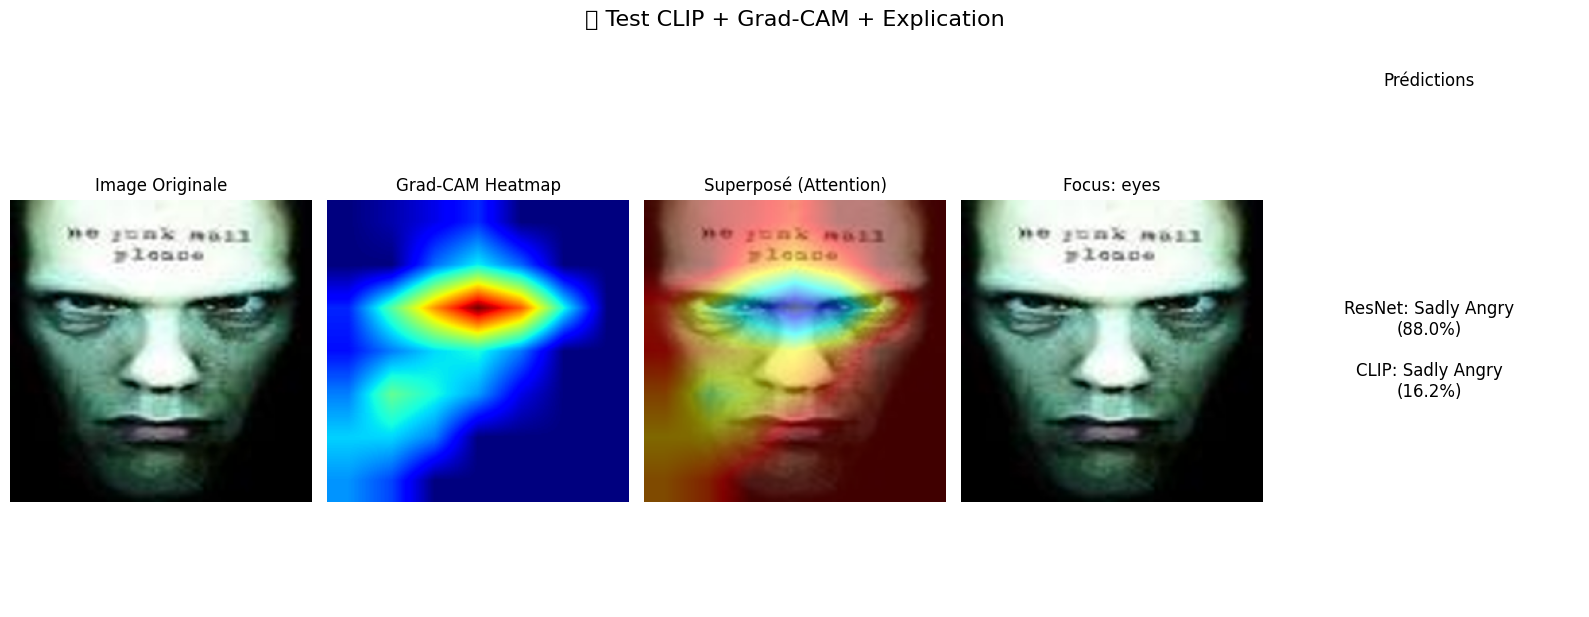

🧠 Explication : The model predicts 'Sadly Angry' because it focuses mainly on the eyes and eyebrows region.
📍 Zone d'attention détectée : eyes
📊 Confiance CLIP : 16.23%


In [73]:
# ====================== TEST CLIP + GRAD-CAM SUR UNE SEULE IMAGE (VERSION CORRIGÉE) ======================
test_image_path = "/content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg"

print(f"🚀 Test CLIP + Grad-CAM sur : {test_image_path}")

# Chargement de l'image
test_img = Image.open(test_image_path).convert("RGB")

# Ensure gradcam is defined
target_layer = model.layer4
gradcam = GradCAM(model, target_layer)

# 1. Prédiction ResNet + Grad-CAM
img_tensor = val_transform(test_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred_cnn = torch.argmax(probs, dim=1).item()

cam = gradcam.generate(img_tensor, pred_cnn)

# 2. Prédiction CLIP
pred_clip_idx, conf_clip = predict_clip(test_img)
pred_clip_name = class_names[pred_clip_idx]

# 3. Analyse de la zone d'attention
focus_area = analyze_attention(cam)

# 4. Explication (maintenant corrigée)
explanation = generate_explanation(pred_cnn, cam)

# 5. Affichage
img_np = np.array(test_img.resize((224, 224)))

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255.0
superimposed = heatmap + np.float32(img_np) / 255.0
superimposed = superimposed / np.max(superimposed)

plt.figure(figsize=(16, 6))

plt.subplot(1, 5, 1)
plt.imshow(img_np)
plt.title("Image Originale")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(superimposed)
plt.title("Superposé (Attention)")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(img_np)
plt.title(f"Focus: {focus_area}")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.text(0.5, 0.5, f"ResNet: {class_names[pred_cnn]}\n({probs[0][pred_cnn]*100:.1f}%)\n\n"
                    f"CLIP: {pred_clip_name}\n({conf_clip*100:.1f}%)",
         ha='center', va='center', fontsize=12)
plt.title("Prédictions")
plt.axis("off")

plt.suptitle("✅ Test CLIP + Grad-CAM + Explication", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("🧠 Explication :", explanation)
print(f"📍 Zone d'attention détectée : {focus_area}")
print(f"📊 Confiance CLIP : {conf_clip*100:.2f}%")

🚀 Test sur 6 images aléatoires du Validation Set

Image 1: True = Happy | ResNet = Sadly Angry | CLIP = Disgust
   → The model predicts 'Sadly Angry' because it focuses mainly on the eyes and eyebrows region.

Image 2: True = Neutral | ResNet = Sadly Angry | CLIP = Sad
   → The model predicts 'Sadly Angry' because it focuses mainly on the eyes and eyebrows region.

Image 3: True = Fear | ResNet = Disgust | CLIP = Surprise
   → The model predicts 'Disgust' because it focuses mainly on the mouth and lower face.

Image 4: True = Sadly Surprised | ResNet = Happily Surprised | CLIP = Fear
   → The model predicts 'Happily Surprised' because it focuses mainly on the eyes and eyebrows region.

Image 5: True = Disgust | ResNet = Fear | CLIP = Disgust
   → The model predicts 'Fear' because it focuses mainly on the eyes and eyebrows region.

Image 6: True = Contempt | ResNet = Contempt | CLIP = Contempt
   → The model predicts 'Contempt' because it focuses mainly on the mouth and lower face.



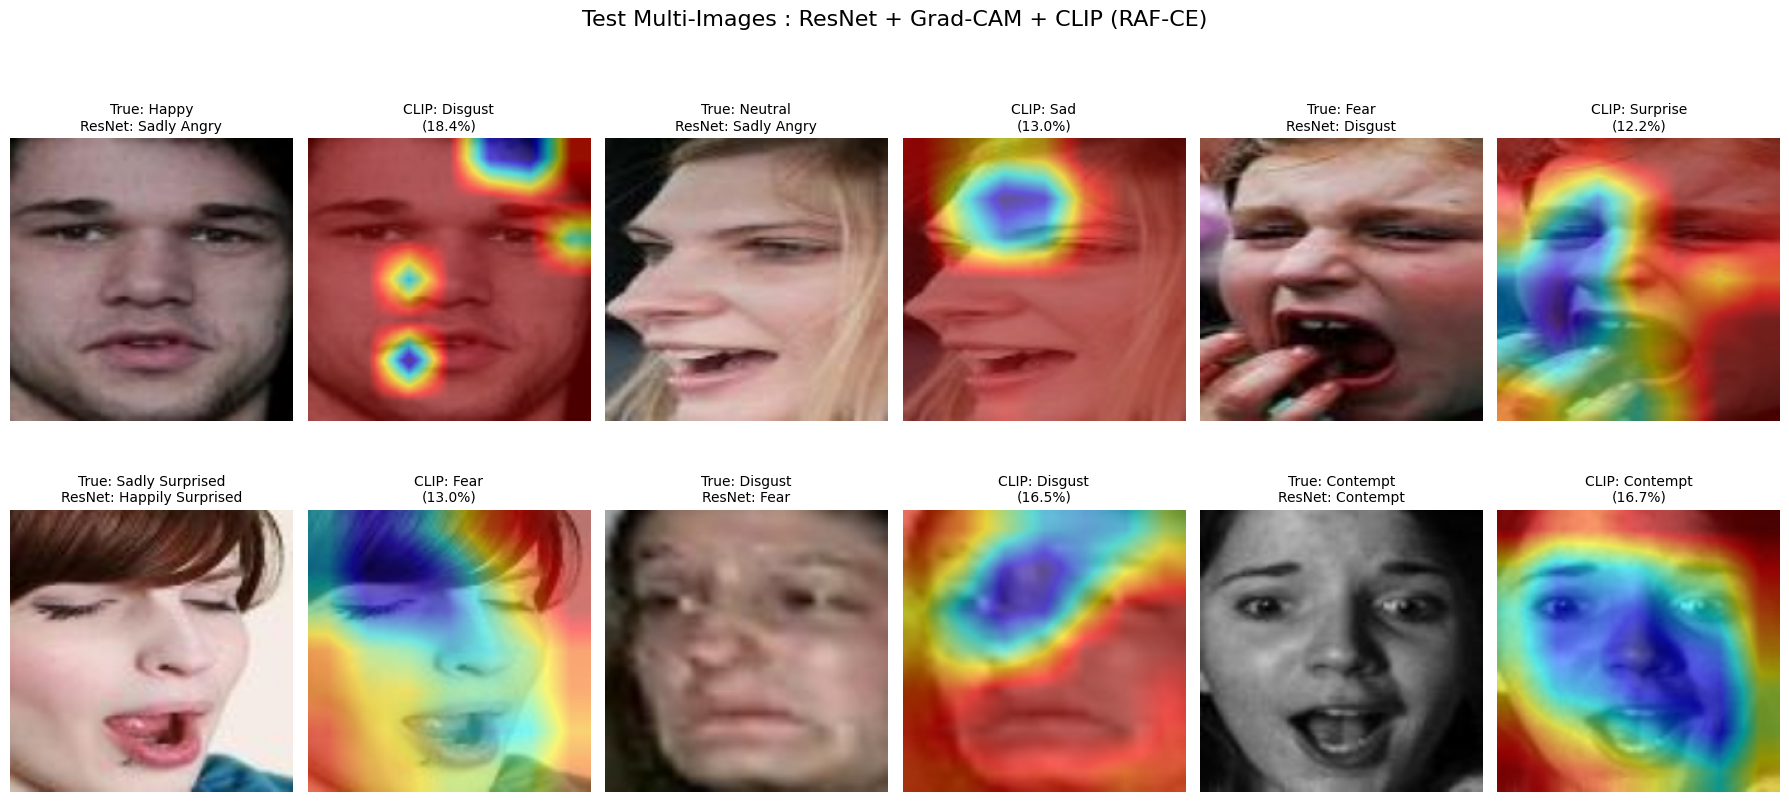

In [74]:
# ====================== TEST SUR PLUSIEURS IMAGES (VERSION CORRIGÉE) ======================
import random

print("🚀 Test sur 6 images aléatoires du Validation Set\n")

# Sélectionner 6 images aléatoires du val_dataset
indices = random.sample(range(len(val_dataset)), 6)

plt.figure(figsize=(18, 12))

for plot_idx, sample_idx in enumerate(indices):
    # Récupérer l'image et le label
    img_tensor, true_label = val_dataset[sample_idx]   # img_tensor est déjà un tensor normalisé

    # Convertir correctement en PIL (correction principale)
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()        # (224, 224, 3)
    img_np = (img_np * 0.5 + 0.5) * 255                       # denormalize
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)         # ← IMPORTANT : uint8
    img_pil = Image.fromarray(img_np).convert("RGB")

    # === Prédiction ResNet ===
    input_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    # === Grad-CAM ===
    cam = gradcam.generate(input_tensor, pred_cnn)

    # === Prédiction CLIP ===
    pred_clip_idx, conf_clip = predict_clip(img_pil)

    # === Explication ===
    explanation = generate_explanation(pred_cnn, cam)

    # === Affichage ===
    img_display = np.array(img_pil.resize((224, 224)))

    # Superimposed Grad-CAM
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed = heatmap + np.float32(img_display) / 255.0
    superimposed = np.clip(superimposed / np.max(superimposed), 0, 1)

    # Plot
    plt.subplot(3, 6, plot_idx*2 + 1)
    plt.imshow(img_display)
    plt.title(f"True: {class_names[true_label]}\nResNet: {class_names[pred_cnn]}", fontsize=10)
    plt.axis("off")

    plt.subplot(3, 6, plot_idx*2 + 2)
    plt.imshow(superimposed)
    plt.title(f"CLIP: {class_names[pred_clip_idx]}\n({conf_clip*100:.1f}%)", fontsize=10)
    plt.axis("off")

    print(f"Image {plot_idx+1}: True = {class_names[true_label]} | "
          f"ResNet = {class_names[pred_cnn]} | CLIP = {class_names[pred_clip_idx]}")
    print(f"   → {explanation}\n")

plt.suptitle("Test Multi-Images : ResNet + Grad-CAM + CLIP (RAF-CE)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [75]:
# ====================== TABLEAU COMPARAISON RESNET vs CLIP ======================
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

print("📊 Calcul des métriques sur tout le Validation Set...\n")

y_true = []
y_pred_resnet = []
y_pred_clip = []

model.eval()
model_clip.eval()

with torch.no_grad():
    for images, labels in val_loader:
        # ResNet
        images = images.to(device)
        outputs = model(images)
        preds_resnet = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred_resnet.extend(preds_resnet)

        # CLIP (une par une car il prend PIL)
        for i in range(images.size(0)):
            img_tensor = images[i]
            img_np = (img_tensor.permute(1,2,0).cpu().numpy() * 0.5 + 0.5) * 255
            img_pil = Image.fromarray(img_np.astype(np.uint8))
            pred_clip, _ = predict_clip(img_pil)
            y_pred_clip.append(pred_clip)

        y_true.extend(labels.cpu().numpy())

# Métriques
acc_resnet = accuracy_score(y_true, y_pred_resnet)
acc_clip = accuracy_score(y_true, y_pred_clip)
f1_resnet = f1_score(y_true, y_pred_resnet, average='macro')
f1_clip = f1_score(y_true, y_pred_clip, average='macro')

print(f"ResNet  → Accuracy: {acc_resnet:.4f} | Macro F1: {f1_resnet:.4f}")
print(f"CLIP    → Accuracy: {acc_clip:.4f} | Macro F1: {f1_clip:.4f}")

# Tableau
comparison = pd.DataFrame({
    "Modèle": ["ResNet18 (Fine-tuned)", "CLIP (ViT-B/32)"],
    "Accuracy": [acc_resnet, acc_clip],
    "Macro F1-Score": [f1_resnet, f1_clip]
})
display(comparison.round(4))

📊 Calcul des métriques sur tout le Validation Set...

ResNet  → Accuracy: 0.4655 | Macro F1: 0.3712
CLIP    → Accuracy: 0.5247 | Macro F1: 0.4028


,Modèle,Accuracy,Macro F1-Score
0,ResNet18 (Fine-tuned),0.4655,0.3712
1,CLIP (ViT-B/32),0.5247,0.4028


In [76]:
!pkill -f streamlit
print("✅ Processus Streamlit arrêté")

✅ Processus Streamlit arrêté


In [77]:
!pkill -f streamlit
!pip install streamlit==1.29.0 --force-reinstall --quiet
print("✅ Streamlit 1.29.0 installé (version plus stable avec LocalTunnel)")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.5 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2

In [78]:
# ====================== VERSION AMÉLIORÉE AVEC MEILLEURE ANALYSE GRADCAM ======================
%%writefile app.py

import streamlit as st
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import cv2
import open_clip

st.set_page_config(page_title="FER-CE Hiba", layout="centered")

st.title("🎯 FER-CE : Reconnaissance Émotions Composées")
st.caption("ResNet18 + CLIP + Grad-CAM — RAF-CE")

class_names = [
    "Neutral", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Angry", "Contempt",
    "Happily Surprised", "Sadly Angry", "Sadly Surprised", "Fearfully Surprised",
    "Angrily Surprised", "Disgustedly Surprised"
]

@st.cache_resource
def load_models():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.6),
        nn.Linear(512, 14)
    )
    model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth", map_location=device))
    model.to(device)
    model.eval()

    model_clip, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    model_clip.to(device)
    model_clip.eval()

    return model, model_clip, preprocess, device

model, model_clip, preprocess, device = load_models()

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

text_prompts = [
    "a person smiling with raised eyebrows", "a person with angry eyebrows and sad mouth",
    "a person with wide eyes and disgusted face", "a smiling person with slight disgust",
    "a sad person with fearful eyes", "an angry person with surprised expression",
    "a sad person with raised eyebrows", "a disgusted person with surprised face",
    "a person with wide eyes and open mouth", "an angry person with disgust expression",
    "a sad person with disgust expression", "a smiling person with anger",
    "a fearful person with anger", "a neutral face"
]
text_tokens = open_clip.tokenize(text_prompts).to(device)

def predict_clip(image):
    image_input = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model_clip.encode_image(image_input)
        text_features = model_clip.encode_text(text_tokens)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        logits = image_features @ text_features.T
        probs = logits.softmax(dim=-1)
    pred = probs.argmax().item()
    return pred, probs[0][pred].item()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        self.model.zero_grad()
        output = self.model(input_image)
        loss = output[0, class_idx]
        loss.backward()
        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

target_layer = model.layer4[-1] if hasattr(model.layer4, '__iter__') else model.layer4
gradcam = GradCAM(model, target_layer)

# ====================== ANALYSE D'ATTENTION AMÉLIORÉE ======================
def analyze_attention(cam):
    h, w = cam.shape
    # Diviser en 3 zones : sourcils/yeux | nez | bouche
    top = np.mean(cam[:int(h*0.35)])      # sourcils + yeux
    middle = np.mean(cam[int(h*0.35):int(h*0.65)])
    bottom = np.mean(cam[int(h*0.65):])   # bouche

    if top > bottom and top > middle:
        return "eyes and eyebrows"
    elif bottom > top and bottom > middle:
        return "mouth and lower face"
    else:
        return "central face (nose/eyes area)"

def generate_explanation(pred_class, cam):
    emotion = class_names[pred_class]
    focus = analyze_attention(cam)
    return f"'{emotion}' - Focus on {focus}."

# ====================== INTERFACE ======================
uploaded_file = st.file_uploader("Charge une image", type=["jpg", "png", "jpeg"])

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Image chargée", use_column_width=True)

    img_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    cam = gradcam.generate(img_tensor, pred_cnn)
    pred_clip, conf_clip = predict_clip(image)
    explanation = generate_explanation(pred_cnn, cam)

    col1, col2 = st.columns(2)
    with col1:
        st.success(f"ResNet: {class_names[pred_cnn]} ({probs[0][pred_cnn]*100:.1f}%)")
    with col2:
        st.success(f"CLIP: {class_names[pred_clip]} ({conf_clip*100:.1f}%)")

    st.subheader("🔥 Grad-CAM - Zones d’attention")

    img_np = np.array(image.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed = heatmap + np.float32(img_np) / 255.0
    superimposed = np.clip(superimposed / np.max(superimposed), 0, 1)

    superimposed_pil = Image.fromarray((superimposed * 255).astype(np.uint8))

    st.image(superimposed_pil, caption="Superimposed Grad-CAM (Attention du modèle)", use_column_width=True)

    st.info(explanation)

st.sidebar.success("Modèles chargés avec succès")

Overwriting app.py


In [62]:
# Cellule 1 : Lancement propre
!streamlit run app.py &>/content/streamlit_logs.txt &
!sleep 8
print("✅ Streamlit lancé en arrière-plan")

✅ Streamlit lancé en arrière-plan


In [ ]:
# Cellule 2 : Lancement du tunnel
!lt --port 8501 --subdomain fer-ce-hiba-final

your url is: https://fer-ce-hiba-final.loca.lt
